In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Setting detectors network

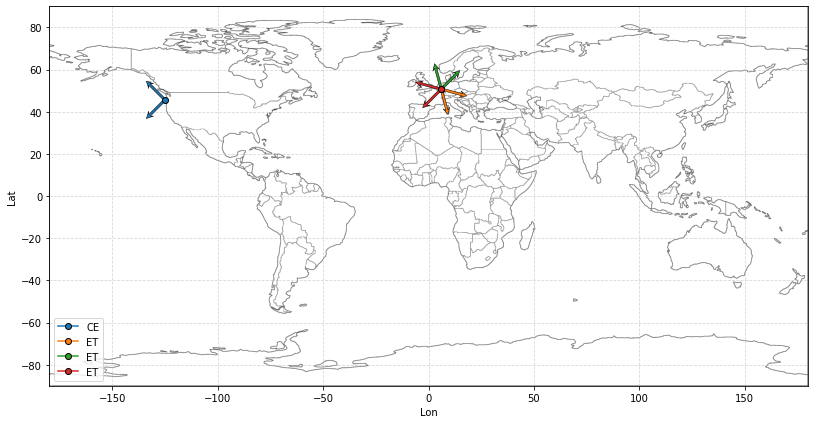

In [2]:
# Cosmic Explorer Coordinates
# https://cosmicexplorer.org/celocations.html
lon_CE = -125.0891
lat_CE = 45.64555

# Einstein Telecope Coordinates (Vaalserberg)
lon_ET = 6.02138
lat_ET = 50.75345

det_CE  = {'name':'CE','lon':lon_CE, 'lat':lat_CE, 'rot':-135, 'shape':90}
det_ET1 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':-120, 'shape':60}

detectors = [det_CE,det_ET1,det_ET2,det_ET3]
fig = gw.draw_detectors(detectors)

## Setting GW source parameters

For GW Polarizations computing it is necessary to declare **15 parameters** (see [https://gwdali.readthedocs.io/en/latest/gw_sources.html](https://gwdali.readthedocs.io/en/latest/gw_sources.html) ):

* Mass parameters: 2 
    * {m1, m2, Mc, eta, M, q, deltaM, inv_eta, ln_eta, ln_Mc}
* Distance Parameters: 1 
    * {dL, inv_dL, inv_dL2, inv_sqrtdL, lnDL, inv_lnDL}
* Spins Parameters: 6 
    * (Cartesian / Spherical / Symmetric-Antisymmetric)
* Extrinsic Parameters: 6 
    * (iota/cos_iota , phi_coal, t_coal, RA, Dec, psi)

In [3]:
# Binary of Neutron Stars (BNS)
m1 = 1.5 # Solar Mass
m2 = 1.4 # Solar Mass
M = m1+m2
eta = m1*m2/M**2
Mc = M*eta**(3./5)

GwPrms = {}
GwPrms['dL']       = 1.55 # Gpc
GwPrms['Mc']       = Mc
GwPrms['eta']      = eta
GwPrms['iota']     = np.pi/4 # radians
GwPrms['t_coal']   = 0.1    # seconds
GwPrms['phi_coal'] = np.pi/4 # radians
GwPrms["psi"]      = np.pi/4 # radians
GwPrms["RA"]       = 45. # degrees
GwPrms["Dec"]      = 30. # degrees

GwPrms["sx1"]  = 0.
GwPrms["sy1"]  = 0.
GwPrms["sz1"]  = 0.1

GwPrms["sx2"]  = 0.
GwPrms["sy2"]  = 0.
GwPrms["sz2"]  = -0.3

### Computing GW strains (detectors outputs)

$$h(f) = F_+h_+(f) + F_{\times}h_{\times}(f)$$

In the current version of GWDALI the user is free to enable/disable GW amplitudes modulations due the Earth rotation by setting the *kwarg* **EarthRotation = True/False**.  

In [4]:
dF = 0.01 # sampling rate (frequency)

freq = np.arange(.1,300,dF)
print(f"Number of frequency points: {len(freq)}")

approx = "IMRPhenomD"

print("Computing waveforms jax ...")
H_dets_jax = gw.get_strain( detectors,
                            GwPrms,
                            freq,
                            approx,
                            enable_jax_waveforms=True,
                            disable_jit=True,
                            EarthRotation=True
                        )



print("Computing waveforms lal ...")
H_dets_lal = gw.get_strain( detectors,
                            GwPrms,
                            freq,
                            approx,
                            enable_jax_waveforms=False,
                            dF=dF,
                            EarthRotation=True
                        )


Number of frequency points: 29990
Computing waveforms jax ...
>> Disabling jax.jit()
Computing waveforms lal ...


### Computing SNR

Below SNR_tot means the root squared sum of the individuals SNR in each detector:

$$SNR_{tot} \equiv \sqrt{ \sum_{a=1}^{N_{det}} SNR_a^2 }$$

In [5]:
SNR_vec, SNR_tot = gw.get_SNR(detectors,GwPrms,approx,enable_jax_waveforms=True) # SNR for JAX waveforms

print(f"Network SNR: {SNR_tot:.2f}")

Network SNR: 36.56


In [6]:
# Auxiliar functions

CharacteristicStrain = lambda x,y: 2*x*np.real( np.sqrt(y*np.conj(y)) )
Phase = lambda x: np.unwrap(np.angle(x))/np.pi

### Plotting signals (Comparing JAX vs LAL)

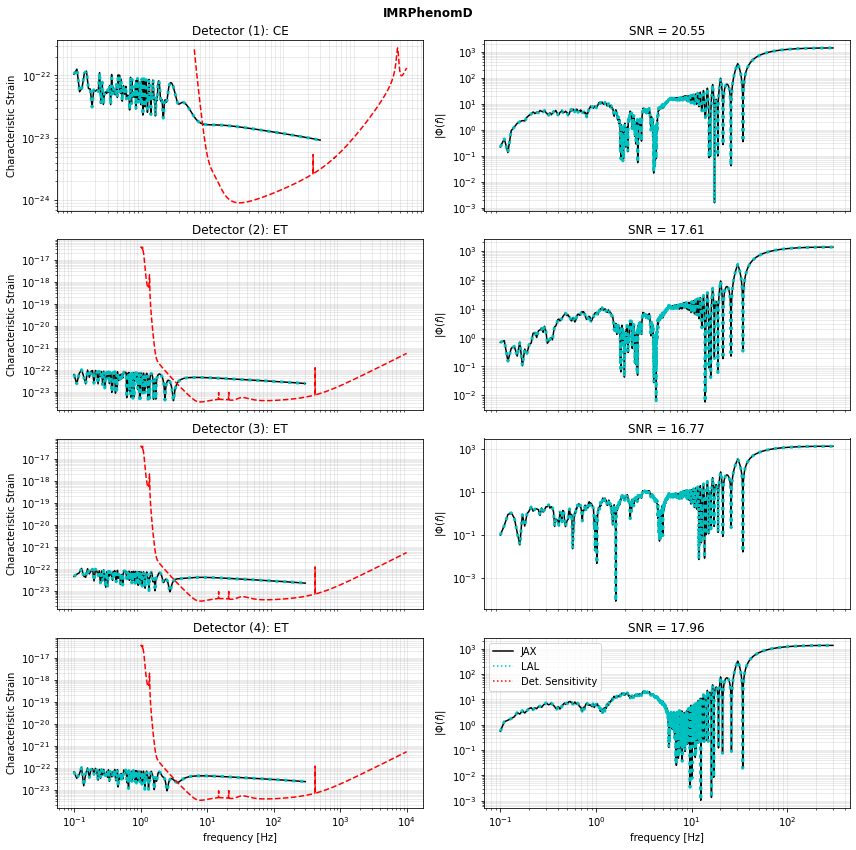

In [7]:
Ndets = len(detectors)

fig = plt.figure(figsize=(12,12))
plt.suptitle(approx,weight="bold")
for i in range(Ndets):
    h1 = H_dets_jax[i]
    h2 = H_dets_jax[i]

    A1 = CharacteristicStrain(freq,h1)
    A2 = CharacteristicStrain(freq,h2)

    Phase1 = Phase(h1)
    Phase2 = Phase(h2)

    Sn, f = gw.lib.Tensors.get_Sn(detectors[i]['name'])
    Sc = np.sqrt(f*Sn)

    plt.subplot(Ndets,2,2*i+1)
    plt.title(f"Detector ({i+1}): {detectors[i]['name']}")
    plt.loglog(freq,A1,'k-')
    plt.loglog(freq,A2,'c:',lw=3)
    plt.loglog(f,Sc,'r--')
    plt.grid(which='both',alpha=.3)
    plt.ylabel("Characteristic Strain")
    if i!=(Ndets-1): plt.xticks([])
    else: plt.xlabel("frequency [Hz]")

    plt.subplot(Ndets,2,2*i+2)
    plt.title(f"SNR = {SNR_vec[i]:.2f}")
    plt.plot(freq,np.abs(Phase1),'k-')
    plt.plot(freq,np.abs(Phase2),'c:',lw=3)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel("$|\Phi(f)|$")
    plt.grid(which='both',alpha=.3)
    if i!=(Ndets-1): plt.xticks([])
    else: plt.xlabel("frequency [Hz]")

plt.plot([],'k-',label='JAX')
plt.plot([],'c:',label='LAL')
plt.plot([],'r:',label='Det. Sensitivity')
plt.legend(loc='best')

plt.tight_layout()